# Tree Analysis

This tutorial demonstrates how to analyze saved results from retrosynthetic tree search. We load the analysis data exported by the [Retrosynthetic Planning tutorial](05_Retrosynthetic_Planning.ipynb) and explore:

- **Policy performance**: rule applicability rate and dead-end analysis
- **Search dynamics**: when routes were discovered during the search
- **Winning rule ranks**: how far from the policy's top prediction the solution rules were
- **Tree shape**: branching profile across depth levels
- **Route details**: per-step breakdown of individual routes

<div class="alert alert-info">
<b>Prerequisites</b>

Run the <a href="05_Retrosynthetic_Planning.ipynb">Retrosynthetic Planning tutorial</a> first to generate the <code>tutorial_results/tree_analysis.json</code> file.
</div>

## 1. Loading saved results

In [1]:
import json
from pathlib import Path

results_path = Path("tutorial_results/tree_analysis.json")
with open(results_path) as f:
    data = json.load(f)

print(f"Target: {data['target_smiles']}")
print(f"Sections: {list(data.keys())}")

Target: NC1(C(=O)N[C@@H](CCO)c2ccc(Cl)cc2)CCN(c2nc[nH]c3nccc2-3)CC1
Sections: ['target_smiles', 'summary', 'branching_profile', 'winning_rule_ranks', 'route_details', 'routes_found_at']


## 2. Search summary

The `summary` section contains the same flat dictionary that `to_stats_dict()` returns: all key metrics in one place.

In [2]:
summary = data["summary"]

print(f"{'Metric':<30} {'Value'}")
print("-" * 50)
for key, value in summary.items():
    print(f"{key:<30} {value}")

Metric                         Value
--------------------------------------------------
num_routes                     153
num_nodes                      3614
num_iter                       300
tree_depth                     9
search_time                    13.6
solved                         True
expansion_calls                221
expansion_successes            221
total_rules_tried              11050
total_rules_succeeded          3533
policy_rules_tried             11050
policy_rules_succeeded         3533
rule_applicability_rate        0.3197
dead_end_nodes                 0
priority_rules_tried           0
priority_rules_succeeded       0
per_priority_source            {}
n_routes_with_priority         0
fraction_routes_with_priority  0.0
first_solution_iteration       5
first_solution_time            0.2776
max_branching_factor           31
mean_branching_factor          16.35
best_route_score               0.156141
mean_winning_rule_rank         6.86


## 3. Policy performance

### Rule applicability rate

The **rule applicability rate** is the fraction of policy-predicted rules that produced valid products (`total_rules_succeeded / total_rules_tried`). It depends on policy quality and on the structural complexity of the target — the same policy can give very different rates on different molecules.

Two related metrics in `summary`:

- `dead_end_nodes`: nodes where every predicted rule failed.
- expansion success rate (`expansion_successes / expansion_calls`): fraction of expansion calls that produced at least one valid child.

The rule applicability rate is per-rule; the expansion success rate is per-expansion. Because the policy returns multiple candidate rules per node, a moderate per-rule rate can coexist with a 100% expansion success rate.

In [3]:
s = summary
print(f"Rule applicability rate: {s['rule_applicability_rate']:.2%}")
print(f"  Rules tried:     {s['total_rules_tried']}")
print(f"  Rules succeeded: {s['total_rules_succeeded']}")
print(f"  Dead-end nodes:  {s['dead_end_nodes']}")
print()
print(f"Expansion efficiency:")
print(f"  Expansion calls:     {s['expansion_calls']}")
print(f"  Expansion successes: {s['expansion_successes']}")
if s['expansion_calls'] > 0:
    print(f"  Success rate:        {s['expansion_successes'] / s['expansion_calls']:.2%}")

Rule applicability rate: 31.97%
  Rules tried:     11050
  Rules succeeded: 3533
  Dead-end nodes:  0

Expansion efficiency:
  Expansion calls:     221
  Expansion successes: 221
  Success rate:        100.00%


### Winning rule ranks

At every retrosynthetic step, the policy proposes a ranked list of reaction rules — the most promising rule first, then the next, and so on. The **winning rule rank** is the position, in that list, of the rule that actually produced a viable disconnection on the way to a successful route.

- Rank 1: the policy's top suggestion was the right one.
- Rank 5: the search had to walk past four better-scored proposals before a working rule appeared.

This answers: **does the policy put the right disconnection at the top of its list, or does the search have to dig deeper?**

Several winning routes typically share the same first few disconnections from the target. To avoid double-counting those shared steps, the statistics and histogram below count each unique retrosynthetic step once (deduped by tree node).

In [4]:
ranks_info = data["winning_rule_ranks"]

if ranks_info:
    # Each tree node corresponds to one retrosynthetic step. Dedupe by node_id
    # so a step shared by multiple winning routes is counted once.
    unique_ranks = {}
    for route in ranks_info:
        for step in route["steps"]:
            unique_ranks.setdefault(step["node_id"], step["rank"])
    all_ranks = list(unique_ranks.values())
    n_steps = len(all_ranks)
    n_top = all_ranks.count(1)

    print(f"{len(ranks_info)} winning routes — {n_steps} distinct retrosynthetic steps")
    print(f"  Top suggestion was correct:   {n_top} / {n_steps} steps ({n_top/n_steps:.0%})")
    print(f"  Average rank of correct rule: {sum(all_ranks)/n_steps:.1f}")
    print(f"  Worst rank seen:              {max(all_ranks)}")
else:
    print("No winning routes found.")

153 winning routes — 308 distinct retrosynthetic steps
  Top suggestion was correct:   124 / 308 steps (40%)
  Average rank of correct rule: 6.9
  Worst rank seen:              49


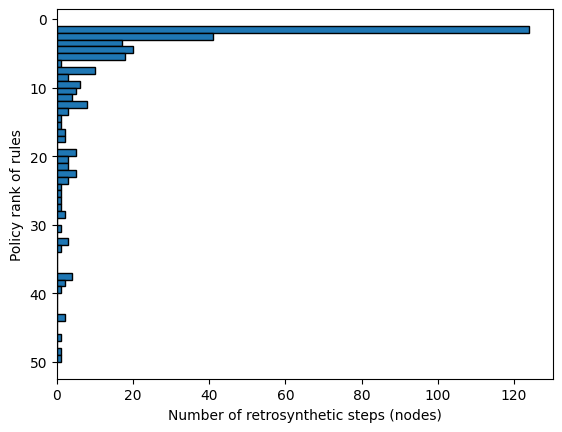

In [5]:
if ranks_info:
    import matplotlib.pyplot as plt

    plt.hist(all_ranks, bins=range(1, max(all_ranks) + 2), edgecolor="black",
             orientation="horizontal")
    plt.ylabel("Policy rank of rules")
    plt.xlabel("Number of retrosynthetic steps (nodes)")
    plt.gca().invert_yaxis()
    plt.show()

Two things to take away:

1. **Policy quality.** A good policy has a tall rank-1 bar and a short tail. A flat or right-leaning histogram means the policy ranks the correct disconnections low.
2. **Cost of a top-K cap.** If you ever limit search to the top-K suggestions per node (a common speedup), this chart shows what you'd lose: anything above rank K disappears. E.g. capping at K = 10 here would lose every step in the tail beyond rank 10.

In [6]:
if ranks_info:
    # Show the first route as an example
    route = ranks_info[0]
    print(f"Example: route ending at node {route['winning_node_id']}")
    print(f"{'Step':<6} {'Node':<8} {'Rule':<8} {'Prob':<10} {'Rank'}")
    print("-" * 40)
    for i, step in enumerate(route["steps"], 1):
        print(f"{i:<6} {step['node_id']:<8} {step['rule_id']:<8} {step['prob']:<10.4f} {step['rank']}")

Example: route ending at node 71
Step   Node     Rule     Prob       Rank
----------------------------------------
1      2        108      0.9037     1
2      32       222      0.0002     12
3      40       255      1.7248     1
4      50       31       1.4067     1
5      71       97       0.4202     1


## 4. Search dynamics

### Route discovery over time

The `routes_found_at` list records when each route was discovered (iteration number and wall-clock time). This reveals the search convergence pattern.

In [7]:
routes_found = data["routes_found_at"]

if routes_found:
    first_iter, first_time = routes_found[0]
    total_iter = summary["num_iter"]
    total_time = summary["search_time"]

    print(f"First solution: iteration {first_iter}/{total_iter} ({first_time:.2f}s / {total_time}s)")
    print(f"Total routes found: {len(routes_found)}")
    print()

    # Routes per quarter of iterations
    quarters = [total_iter * q // 4 for q in range(1, 5)]
    print("Routes found by iteration:")
    for q_iter in quarters:
        count = sum(1 for it, _ in routes_found if it <= q_iter)
        print(f"  By iteration {q_iter:>4d}: {count} routes")
else:
    print("No routes found during search.")
    print(f"Search ran for {summary['num_iter']} iterations in {summary['search_time']}s")

First solution: iteration 5/300 (0.28s / 13.6s)
Total routes found: 126

Routes found by iteration:
  By iteration   75: 17 routes
  By iteration  150: 61 routes
  By iteration  225: 100 routes
  By iteration  300: 126 routes


### Branching profile

The branching profile shows the mean number of children per expanded node at each depth level. This reveals how the tree fans out and whether deeper nodes have fewer expansion options.

Depth    Mean children    Expanded nodes  
---------------------------------------------
0        22.0             1               
1        16.55            22              
2        16.24            41              
3        16.62            37              
4        16.27            37              
5        18.27            33              
6        15.04            24              
7        15.44            16              
8        13.3             10              

Overall: max branching = 31, mean branching = 16.35


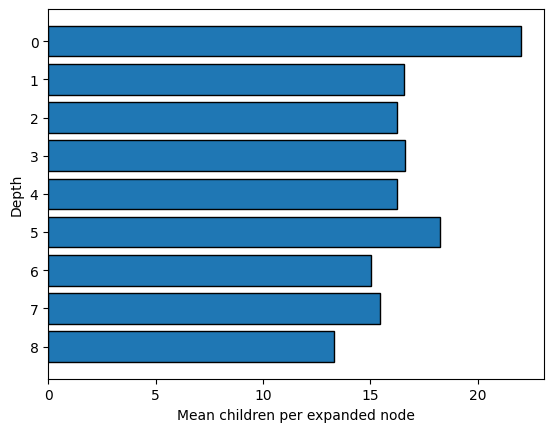

In [8]:
import matplotlib.pyplot as plt

profile = data["branching_profile"]

print(f"{'Depth':<8} {'Mean children':<16} {'Expanded nodes':<16}")
print("-" * 45)
for depth, info in sorted(profile.items(), key=lambda x: int(x[0])):
    print(f"{depth:<8} {info['mean_children']:<16} {info['nodes']:<16}")

print(f"\nOverall: max branching = {summary['max_branching_factor']}, "
      f"mean branching = {summary['mean_branching_factor']}")

depths = sorted(profile.keys(), key=int)
means = [profile[d]["mean_children"] for d in depths]
plt.barh(depths, means, edgecolor="black")
plt.xlabel("Mean children per expanded node")
plt.ylabel("Depth")
plt.gca().invert_yaxis()
plt.show()

## 5. Route details

Each saved route includes the per-step breakdown: rule used, its policy probability, the node's evaluation value, visit count, and whether that step's precursors are fully solved.

In [9]:
route_details = data["route_details"]

if route_details:
    # Find the best-scoring route
    best = max(route_details, key=lambda r: r["route_score"])
    print(f"Best route (node {best['node_id']}, score={best['route_score']:.6f}, "
          f"length={best['route_length']} steps):")
    print()
    for step in best["steps"]:
        status = "solved" if step["is_solved"] else "open"
        print(f"  Depth {step['depth']}: node {step['node_id']}, rule={step['rule_id']}, "
              f"prob={step['prob']:.4f}, value={step['init_value']:.4f}, "
              f"visits={step['visits']}, {status}, {step['n_precursors']} precursors")
else:
    print("No route details available.")

Best route (node 3561, score=0.156141, length=3 steps):

  Depth 1: node 21, rule=613, prob=0.0000, value=0.5000, visits=18, open, 1 precursors
  Depth 2: node 952, rule=255, prob=0.3908, value=0.5000, visits=4, open, 2 precursors
  Depth 3: node 3561, rule=3862, prob=0.0005, value=0.5000, visits=0, solved, 2 precursors


Route summary (153 routes):
  Length: min=2, max=9, mean=6.3
  Score:  min=0.050048, max=0.156141, mean=0.078255


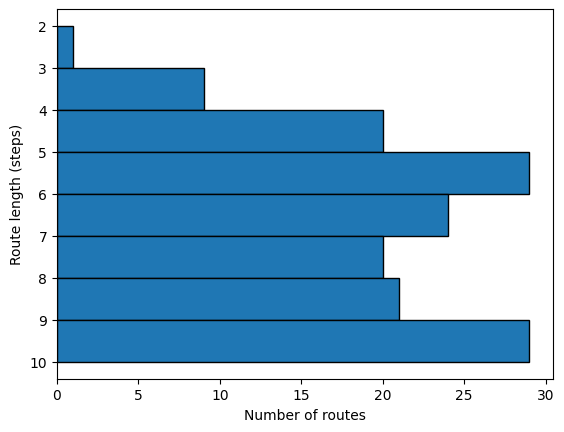

In [10]:
if route_details:
    import matplotlib.pyplot as plt

    lengths = [r["route_length"] for r in route_details]
    scores = [r["route_score"] for r in route_details]

    print(f"Route summary ({len(route_details)} routes):")
    print(f"  Length: min={min(lengths)}, max={max(lengths)}, mean={sum(lengths)/len(lengths):.1f}")
    print(f"  Score:  min={min(scores):.6f}, max={max(scores):.6f}, mean={sum(scores)/len(scores):.6f}")

    plt.hist(lengths, bins=range(min(lengths), max(lengths) + 2), edgecolor="black",
             orientation="horizontal")
    plt.ylabel("Route length (steps)")
    plt.xlabel("Number of routes")
    plt.gca().invert_yaxis()
    plt.show()

## 6. Batch analysis from CSV

When running `run_search` or the SAScore benchmark over many targets, results are saved to `tree_search_stats.csv`. Here we show how to load and compare across targets.

In [11]:
import csv

csv_path = Path("tutorial_results/tree_search_stats.csv")
if csv_path.exists():
    with open(csv_path) as f:
        reader = csv.DictReader(f)
        rows = list(reader)

    print(f"Loaded {len(rows)} search results from CSV")
    print(f"Columns: {list(rows[0].keys())}")
    print()
    for row in rows[:5]:
        smiles = row.get("target_smiles", "N/A")
        solved = row.get("solved", "N/A")
        routes = row.get("num_routes", "N/A")
        rate = row.get("rule_applicability_rate", "N/A")
        print(f"  {smiles[:50]:<50} solved={solved} routes={routes} applicability={rate}")
else:
    print(f"{csv_path} not found. Run tutorial 05 first.")

Loaded 1 search results from CSV
Columns: ['num_routes', 'num_nodes', 'num_iter', 'tree_depth', 'search_time', 'solved', 'expansion_calls', 'expansion_successes', 'total_rules_tried', 'total_rules_succeeded', 'policy_rules_tried', 'policy_rules_succeeded', 'rule_applicability_rate', 'dead_end_nodes', 'priority_rules_tried', 'priority_rules_succeeded', 'per_priority_source', 'n_routes_with_priority', 'fraction_routes_with_priority', 'first_solution_iteration', 'first_solution_time', 'max_branching_factor', 'mean_branching_factor', 'best_route_score', 'mean_winning_rule_rank', 'target_smiles']

  NC1(C(=O)N[C@@H](CCO)c2ccc(Cl)cc2)CCN(c2nc[nH]c3nc solved=True routes=153 applicability=0.3197


## 7. Interpretation guide

### Diagnosing common issues

| Symptom | What to check | Possible fix |
| --- | --- | --- |
| No routes found | `first_solution_iteration` is None | Increase `max_iterations` / `max_time` |
| Low applicability rate (< 20%) | `rule_applicability_rate` | Retrain policy with more data, check rule quality |
| High winning rule rank (> 5) | `mean_winning_rule_rank` | Policy needs more training data for these reaction types |
| Many dead-end nodes | `dead_end_nodes` vs `expansion_calls` | Rules may be too specific, or building blocks too limited |
| Late first solution | `first_solution_iteration` / `num_iter` | Try higher `c_ucb` for more exploration |
| Low branching at depth 0 | `branching_profile` | Few rules apply to the target — may need broader rule set |

### Comparing policies

When comparing two policies on the same targets:
1. **Rule applicability rate**: higher is better (more efficient search)
2. **Mean winning rule rank**: lower is better (policy predicts correct rules at the top)
3. First solution iteration: lower is better (faster convergence)
4. Number of routes: more routes give chemists more choices
5. **Best route score**: higher is better (better route quality)

## Summary

| Data | Source | Description |
| --- | --- | --- |
| `summary` | `tree.to_stats_dict()` | Flat dict with all key metrics |
| `branching_profile` | `tree.branching_profile()` | Mean branching factor per depth |
| `winning_rule_ranks` | `tree.winning_rule_ranks()` | Rank of winning rule at each step |
| `route_details` | `tree.route_details(nid)` | Per-step breakdown of routes |
| `routes_found_at` | `tree.stats.routes_found_at` | Route discovery timing |

All these are saved by tutorial 05 into `tutorial_results/tree_analysis.json`. For batch analysis, `run_search` and the SAScore benchmark write `tree_search_stats.csv` with the same summary metrics.